# Sesión 3 — Flujo de carga DC y DC-OPF

**Objetivo:** Derivar y resolver el flujo de carga en continua (DC) a partir de la Ybus. Formular y resolver el DC-OPF como problema de programación lineal (LP) con Pyomo + HiGHS.

**Duración estimada:** 90 minutos

---
**Integrantes del grupo:** _Escribe aquí los nombres_

**Fecha:** ___________

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandapower as pp
import pandapower.networks as pn
import networkx as nx
import pyomo.environ as pyo
from IPython.display import display

print('Entorno listo ✓')

Entorno listo ✓


---

## Red de trabajo desde Pandapower

En esta sesión, se trabajará con la red de 14 barras de IEEE, que se encuentra disponible en el repositorio de Pandapower. Para cargar esta red, se puede utilizar el siguiente código:

```python 
net = pn.case14()
# Se puede visualizar el sistema:
import pandapower.plotting as plot
plot.simple_plot(net, plot_gens=True)
```

---
## 1. Flujo de carga DC

El flujo de carga DC es una **linealización** del flujo AC. Asume tensiones constantes (1 pu) y ángulos pequeños. El resultado es un sistema lineal $ P = B_r \cdot \theta $ donde:

- $P$ = inyecciones de potencia activa en barras (excepto el slack)
- $B_r$ = submatriz de la Ybus (parte imaginaria, sin la fila/columna del slack)
- $\theta$ = ángulos de tensión

In [19]:
# ── Cargar red y extraer datos ──────────────────────────────────────────────
net = pn.case14()
pp.runpp(net)

from pandapower.pd2ppc import _pd2ppc
from pandapower.shortcircuit.impedance import _calc_ybus

ppc, ppci = _pd2ppc(net)
_calc_ybus(ppci)
Ybus = ppci['internal']['Ybus'].todense()
Sbase = ppci['baseMVA']

# Número de barras
N = len(net.bus)

# ── Construir matriz B y vectores de generación/carga (en pu) ───────────────
# La parte imaginaria de Ybus es la matriz B (con signo cambiado)
B = -np.imag(Ybus)
print('Primeros elementos de B:')
print(B[:3, :3])



Primeros elementos de B:
[[ 19.44707021 -15.26308652  -0.        ]
 [-15.26308652  30.2721154   -4.78186315]
 [ -0.          -4.78186315   9.82238013]]


In [20]:
# ── Vector de generación e inyecciones netas P = Pgen - Pload ───────────────
P_gen = np.zeros(N)
for _, row in net.gen.iterrows():
    P_gen[row['bus']] += row['p_mw'] / Sbase

P_load = np.zeros(N)
for _, row in net.load.iterrows():
    P_load[row['bus']] += row['p_mw'] / Sbase

P_net = P_gen - P_load

# ── Resolver el flujo DC ─────────────────────────────────────────────────────
# La barra 0 es el slack → eliminar fila y columna 0
B_r = B[1:, 1:]   # submatriz sin slack
P_r = P_net[1:]   # inyecciones sin slack

# TODO: resolver el sistema B_r * theta_r = P_r
theta_r = np.linalg.solve(B_r, P_r)

# --- Añadir el ángulo del slack (= 0) al principio
theta = np.insert(theta_r, 0, 0.0)
print('Ángulos nodales calculados (rad):')
print(np.round(theta, 4))

print('\nÁngulos nodales en grados (°):')
print(np.round(np.degrees(theta), 2))

Ángulos nodales calculados (rad):
[ 0.     -0.1016 -0.2552 -0.2129 -0.1826 -0.3036 -0.2861 -0.2861 -0.322
 -0.3276 -0.3201 -0.3267 -0.3321 -0.3543]

Ángulos nodales en grados (°):
[  0.    -5.82 -14.62 -12.2  -10.46 -17.39 -16.39 -16.39 -18.45 -18.77
 -18.34 -18.72 -19.03 -20.3 ]


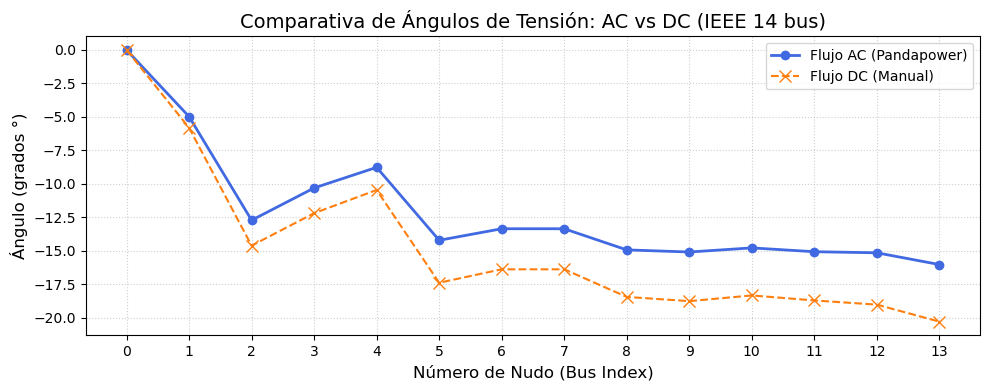

In [21]:
# ── Comparar ángulos DC vs AC ────────────────────────────────────────────────
theta_ac_deg = net.res_bus['va_degree'].values
theta_dc_deg = np.degrees(theta)
nodos = np.arange(len(theta_ac_deg)) 

# TODO: representa ambos perfiles de ángulos en la misma figura
fig, ax = plt.subplots(figsize=(10, 4))


# ── Crear la figura ─────────────────────────────────────────────────────────

# Graficar perfil AC
ax.plot(nodos, theta_ac_deg, 'o-', label='Flujo AC (Pandapower)', color='royalblue', linewidth=2)

# Graficar perfil DC
ax.plot(nodos, theta_dc_deg, 'x--', label='Flujo DC (Manual)', color='tab:orange', markersize=8)

# Personalización del gráfico
ax.set_title('Comparativa de Ángulos de Tensión: AC vs DC (IEEE 14 bus)', fontsize=14)
ax.set_xlabel('Número de Nudo (Bus Index)', fontsize=12)
ax.set_ylabel('Ángulo (grados °)', fontsize=12)
ax.set_xticks(nodos)  
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend()

# ── Guardar y mostrar ───────────────────────────────────────────────────────
plt.tight_layout()

plt.savefig('./resultados/sesion03_angulos_dc_vs_ac.png', dpi=150)
plt.show()

---
## 2. Formulación del DC-OPF

El DC-OPF añade una función objetivo (minimizar coste) y restricciones de capacidad de línea al flujo DC. Es un **problema de programación lineal (LP)**.

### Formulación matemática

**Conjuntos:**
- $\mathcal{N}$: barras
- $\mathcal{G}$: generadores
- $\mathcal{L}$: ramas

**Variables:**
- $p_g$ [pu]: potencia activa del generador $g$
- $\theta_i$ [rad]: ángulo de tensión en la barra $i$
- $f_l$ [pu]: flujo de potencia por la rama $l$

**Función objetivo:**
$$\min \sum_{g \in \mathcal{G}} c_g \cdot p_g $$

**Restricciones:**
$$p_{g,\min} \leq p_g \leq p_{g,\max}, \quad \forall g$$
$$\sum_{g: bus(g)=i} p_g - P_{d,i} = \sum_j Bdc_{ij} \theta_j, \quad \forall i \neq slack$$
$$f_l = \sum_{i} T_{li} \cdot \theta_i, \quad \forall l$$
$$-f_{l,\max} \leq f_l \leq f_{l,\max}, \quad \forall l$$
$$\theta_{slack} = 0$$

---
## 2. Formulación del DC-OPF

El DC-OPF añade una función objetivo (minimizar coste) y restricciones de capacidad de línea al flujo DC. Es un **problema de programación lineal (LP)**.


### Formulación matemática

**Conjuntos:**
- $\mathcal{N}$: barras (incluida la slack)
- $\mathcal{G}$: generadores
- $\mathcal{G}_i \subseteq \mathcal{G}$: generadores conectados a la barra $i$
- $\mathcal{L}$: ramas

**Parámetros:**
- $c_g$ [€/MWh]: coste marginal del generador $g$
- $p_{g,\min}, p_{g,\max}$ [pu]: límites de potencia del generador $g$
- $P_{d,i}$ [pu]: demanda en la barra $i$
- $x_l$ [pu]: reactancia de la rama $l$
- $f_{l,\max}$ [pu]: capacidad de la rama $l$
- $B'_{ij}$ [pu$^{-1}$]: elementos de la matriz nodal DC, definida arriba
- $slack \in \mathcal{N}$: barra de referencia angular

**Variables:**
- $p_g$ [pu]: potencia activa del generador $g$
- $\theta_i$ [rad]: ángulo de tensión en la barra $i$
- $f_l$ [pu]: flujo por la rama $l$

**Función objetivo:**

$$
\min \sum_{g \in \mathcal{G}} c_g \cdot p_g
$$

**Restricciones:**

Balance nodal de potencia (en **todas** las barras, expresado vía $\mathbf{B}'$):

$$
\sum_{g \in \mathcal{G}_i} p_g - P_{d,i} = \sum_{j \in \mathcal{N}} B'_{ij} \cdot \theta_j, \quad \forall i \in \mathcal{N}
$$

En forma matricial compacta:

$$
\mathbf{P}^{iny} = \mathbf{B}' \boldsymbol{\theta}
$$

donde $P^{iny}_i = \sum_{g \in \mathcal{G}_i} p_g - P_{d,i}$.

Relación flujo–ángulo (modelo DC, definida por rama):

$$
f_l = \frac{\theta_{from(l)} - \theta_{to(l)}}{x_l}, \quad \forall l \in \mathcal{L}
$$

Límites de generación:

$$
p_{g,\min} \leq p_g \leq p_{g,\max}, \quad \forall g \in \mathcal{G}
$$

Límites de capacidad de línea:

$$
-f_{l,\max} \leq f_l \leq f_{l,\max}, \quad \forall l \in \mathcal{L}
$$

Referencia angular:

$$
\theta_{slack} = 0
$$


In [22]:
# %% Parámetros base del sistema
S_BASE = net.sn_mva  # MVA base (típicamente 100 MVA)
N_BUS = len(net.bus)
print(f"S_base = {S_BASE} MVA")
print(f"Número de barras: {N_BUS}")

S_base = 100 MVA
Número de barras: 14


In [23]:
# %% Estructura de generadores
# Pandapower tiene varios tipos: gen (PV), ext_grid (slack), sgen (estáticos)
# Para DC-OPF unificamos todos los que tienen coste asociado

generadores = []  # lista de dicts con info de cada generador

# Generadores convencionales
for idx, gen in net.gen.iterrows():
    generadores.append({
        'id': f'gen_{idx}',
        'bus': int(gen.bus),
        'p_min': gen.min_p_mw / S_BASE,   # pu
        'p_max': gen.max_p_mw / S_BASE,   # pu
        'tipo': 'gen',
        'pp_idx': idx,
    })

# Slack (ext_grid). Si no tiene límites definidos, usamos valores grandes
for idx, ext in net.ext_grid.iterrows():
    p_min = ext.get('min_p_mw', -1e3) / S_BASE
    p_max = ext.get('max_p_mw',  1e3) / S_BASE
    generadores.append({
        'id': f'ext_{idx}',
        'bus': int(ext.bus),
        'p_min': p_min,
        'p_max': p_max,
        'tipo': 'ext',
        'pp_idx': idx,
    })

# Costes lineales: net.poly_cost contiene cp1_eur_per_mw (coste lineal)
# Para DC-OPF asumimos coste lineal: c_g * p_g
def coste_lineal(tipo, idx):
    """Devuelve el coste marginal en €/MW (asumimos cuadrático=0)."""
    fila = net.poly_cost[
        (net.poly_cost.et == ('gen' if tipo == 'gen' else 'ext_grid')) &
        (net.poly_cost.element == idx)
    ]
    if len(fila) == 0:
        return 0.0
    return float(fila.cp1_eur_per_mw.iloc[0])

for g in generadores:
    g['coste'] = coste_lineal(g['tipo'], g['pp_idx'])

print(f"Total generadores: {len(generadores)}")
df_gen = pd.DataFrame(generadores)
print(df_gen[['id', 'bus', 'p_min', 'p_max', 'coste']])

Total generadores: 5
      id  bus  p_min  p_max  coste
0  gen_0    1    0.0  1.400   20.0
1  gen_1    2    0.0  1.000   40.0
2  gen_2    5    0.0  1.000   40.0
3  gen_3    7    0.0  1.000   40.0
4  ext_0    0    0.0  3.324   20.0


In [29]:
# %% Demandas por barra (sumamos todas las cargas conectadas a cada barra)
P_d = np.zeros(N_BUS)
for _, load in net.load.iterrows():
    if load.in_service:
        P_d[int(load.bus)] += load.p_mw / S_BASE   # pu

# --- Resumen de la demanda calculada ---
p_total_mw = P_d.sum() * S_BASE
print(f"Demanda total del sistema: {p_total_mw:.2f} MW")

print("\nDesglose de demanda por barra (MW):")
for i, p_pu in enumerate(P_d):
    if p_pu > 0:
        print(f"  - Barra {i:2}: {p_pu * S_BASE:6.2f} MW")

# Barra slack (referencia angular)
slack_bus = int(net.ext_grid.bus.iloc[0])
print(f"Barra slack: {slack_bus}")

Demanda total del sistema: 259.00 MW

Desglose de demanda por barra (MW):
  - Barra  1:  21.70 MW
  - Barra  2:  94.20 MW
  - Barra  3:  47.80 MW
  - Barra  4:   7.60 MW
  - Barra  5:  11.20 MW
  - Barra  8:  29.50 MW
  - Barra  9:   9.00 MW
  - Barra 10:   3.50 MW
  - Barra 11:   6.10 MW
  - Barra 12:  13.50 MW
  - Barra 13:  14.90 MW
Barra slack: 0


In [25]:
# %% Datos de las ramas para los flujos
# Necesitamos: índice de rama, from_bus, to_bus, x_pu, f_max_pu
ramas = []
for idx, line in net.line.iterrows():
    if not line.in_service:
        continue
    i, j = int(line.from_bus), int(line.to_bus)
    v_base = net.bus.loc[i, 'vn_kv']
    x_pu = (line.x_ohm_per_km * line.length_km) * S_BASE / (v_base ** 2)
    # Capacidad: max_i_ka * V_base * sqrt(3) → MVA
    s_max = line.max_i_ka * v_base * np.sqrt(3)
    ramas.append({
        'id': f'l_{idx}', 'from': i, 'to': j,
        'x_pu': x_pu, 'f_max': s_max / S_BASE,
    })

for idx, trafo in net.trafo.iterrows():
    if not trafo.in_service:
        continue
    i, j = int(trafo.hv_bus), int(trafo.lv_bus)
    x_pu = (trafo.vk_percent / 100.0) * S_BASE / trafo.sn_mva
    ramas.append({
        'id': f't_{idx}', 'from': i, 'to': j,
        'x_pu': x_pu, 'f_max': trafo.sn_mva / S_BASE,
    })

print(f"Total ramas: {len(ramas)}")

Total ramas: 20


In [ ]:
# %% Construcción del modelo Pyomo
model = pyo.ConcreteModel(name="DC-OPF con matriz B'")

# --- CONJUNTOS ---
model.N = pyo.Set(initialize=range(N_BUS), doc='Barras')
model.G = pyo.Set(initialize=range(len(generadores)), doc='Generadores')
model.L = pyo.Set(initialize=range(len(ramas)), doc='Ramas')

# --- PARÁMETROS ---
# Matriz B' como diccionario (i,j) -> valor (Pyomo prefiere dicts para Param 2D)
B_dict = {(i, j): B[i, j] for i in range(N_BUS) for j in range(N_BUS)}
model.B = pyo.Param(model.N, model.N, initialize=B_dict, doc="Matriz B' DC")

# Demanda por barra
model.Pd = pyo.Param(model.N, initialize={i: P_d[i] for i in range(N_BUS)})

# Datos de generadores
model.coste = pyo.Param(model.G, initialize={g: generadores[g]['coste'] for g in range(len(generadores))})
model.p_min = pyo.Param(model.G, initialize={g: generadores[g]['p_min'] for g in range(len(generadores))})
model.p_max = pyo.Param(model.G, initialize={g: generadores[g]['p_max'] for g in range(len(generadores))})
model.bus_g = pyo.Param(model.G, initialize={g: generadores[g]['bus'] for g in range(len(generadores))},
                        within=pyo.NonNegativeIntegers)

# Datos de ramas
model.x_l    = pyo.Param(model.L, initialize={l: ramas[l]['x_pu'] for l in range(len(ramas))})
model.fmax_l = pyo.Param(model.L, initialize={l: ramas[l]['f_max'] for l in range(len(ramas))})
model.from_l = pyo.Param(model.L, initialize={l: ramas[l]['from'] for l in range(len(ramas))},
                         within=pyo.NonNegativeIntegers)
model.to_l   = pyo.Param(model.L, initialize={l: ramas[l]['to']   for l in range(len(ramas))},
                         within=pyo.NonNegativeIntegers)

# --- VARIABLES --- Definimos los limites de generacion y de flujo por las lineas
def _bounds_pg(m, g):
    return (m.p_min[g], m.p_max[g])
model.p = pyo.Var(model.G, bounds=_bounds_pg, doc='Potencia activa generador [pu]')

model.theta = pyo.Var(model.N, within=pyo.Reals, doc='Ángulo de tensión [rad]')

def _bounds_f(m, l):
    return (-m.fmax_l[l], m.fmax_l[l])
model.f = pyo.Var(model.L, bounds=_bounds_f, doc='Flujo de potencia por rama [pu]')

In [27]:
# --- FUNCIÓN OBJETIVO ---
def obj_rule(m):
    # Suma de (Potencia generada * S_BASE * Coste por MW)
    return sum(m.p[g] * S_BASE * m.coste[g] for g in m.G)

model.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

# --- RESTRICCIONES ---

# 1. Flujo en las ramas
def flujo_rama_rule(m, l):
    # f = (theta_from - theta_to) / x
    return m.f[l] == (m.theta[m.from_l[l]] - m.theta[m.to_l[l]]) / m.x_l[l]

model.res_flujo = pyo.Constraint(model.L, rule=flujo_rama_rule)

# 2. Balance de potencia en cada nudo 
def balance_nudo_rule(m, i):
    # Generación total en el nudo i
    gen_total = sum(m.p[g] for g in m.G if m.bus_g[g] == i)
    
    # Flujo neto que sale del nudo i hacia otros nudos
    # Usamos la matriz B: sum(B_ij * theta_j)
    flujo_red = sum(m.B[i, j] * m.theta[j] for j in m.N)
    
    # Balance: Gen - Demanda = Flujo que se va por la red
    return gen_total - m.Pd[i] == flujo_red

model.res_balance = pyo.Constraint(model.N, rule=balance_nudo_rule)

# 3. Referencia angular (Slack bus)
# Fijamos el ángulo de la barra slack a 0 para que el sistema tenga solución única
model.theta[slack_bus].fix(0)

In [28]:
# ── Resolver con HiGHS ───────────────────────────────────────────────────────
solver = pyo.SolverFactory('highs')
resultado = solver.solve(model, tee=False)

print('Estado:', resultado.solver.termination_condition)
print(f'Coste óptimo: {pyo.value(model.obj):.2f} €/h')

# TODO: imprime la despacho óptimo de cada generador (en MW)
print('\nDespacho óptimo:')
print("-" * 30)
for g in model.G:
    gen_id = generadores[g]['id']
    p_mw = pyo.value(model.p[g]) * S_BASE
    print(f"Generador {gen_id}: {p_mw:8.2f} MW")
print("-" * 30)
   # pass  # TODO: imprime generador g y su potencia óptima en MW

Estado: optimal
Coste óptimo: 5411.58 €/h

Despacho óptimo:
------------------------------
Generador gen_0:   140.00 MW
Generador gen_1:     0.00 MW
Generador gen_2:     0.00 MW
Generador gen_3:     0.00 MW
Generador ext_0:   130.58 MW
------------------------------


In [30]:
# %% Reporte de carga de líneas y transformadores
print(f"\n{'='*60}")
print(f"{'ESTADO DE CARGA DE LAS RAMAS':^60}")
print(f"{'='*60}")
print(f"{'ID':<10} | {'Desde':<6} | {'Hacia':<6} | {'Flujo [MW]':<12} | {'Límite [MW]':<12} | {'Carga %'}")
print("-" * 75)

for l in model.L:
    flujo_mw = pyo.value(model.f[l]) * S_BASE
    limite_mw = model.fmax_l[l] * S_BASE
    
    # Calculamos el porcentaje de carga (valor absoluto porque el flujo puede ser negativo)
    carga_porcentaje = (abs(flujo_mw) / limite_mw) * 100
    
    # Marcamos con un aviso si está cerca del límite (>99%)
    aviso = " <-- ¡CONGESTIÓN!" if carga_porcentaje > 99.9 else ""
    
    print(f"{ramas[l]['id']:<10} | {ramas[l]['from']:<6} | {ramas[l]['to']:<6} | "
          f"{abs(flujo_mw):>10.2f} | {limite_mw:>11.2f} | {carga_porcentaje:>6.1f}% {aviso}")

print("-" * 75)


                ESTADO DE CARGA DE LAS RAMAS                
ID         | Desde  | Hacia  | Flujo [MW]   | Límite [MW]  | Carga %
---------------------------------------------------------------------------
l_0        | 0      | 1      |      77.97 |     9900.00 |    0.8% 
l_1        | 0      | 4      |      63.69 |     9900.00 |    0.6% 
l_2        | 1      | 2      |      80.34 |     9900.00 |    0.8% 
l_3        | 1      | 3      |      69.25 |     9900.00 |    0.7% 
l_4        | 1      | 4      |      55.16 |     9900.00 |    0.6% 
l_5        | 2      | 3      |      21.60 |     9900.00 |    0.2% 
l_6        | 3      | 4      |      62.18 |     9900.00 |    0.6% 
l_7        | 5      | 10     |       7.94 |     9900.00 |    0.1% 
l_8        | 5      | 11     |       8.98 |     9900.00 |    0.1% 
l_9        | 5      | 12     |      21.69 |     9900.00 |    0.2% 
l_10       | 8      | 9      |       6.89 |     9900.00 |    0.1% 
l_11       | 8      | 13     |      12.16 |     9900.00 

---
## Reflexión final

_Responde brevemente en esta celda:_

1. ¿Qué generador resulta despachado al máximo en la solución óptima? ¿Qué tiene de especial su coste? 
    El generador gen 0 es el despachado al maximo con 140MW, la razon es que su coste es el menor por mW

2. ¿Qué restricciones están **activas** en la solución (es decir, se cumplen con igualdad)? ¿Qué interpretación física tienen?
Solo estan activas las restricciones del generador gen 0 con su potencia maxima y las restricciones del balance de potencias. Se cumple la restriccion de gen 0 con igualdad dado que se busca maximizar la generacion de gen 0 para minimizar el coste de generacion
    
3. El DC-OPF es una linealización. ¿Qué fenómenos físicos ignora que el AC-OPF sí considera?

El DC-OPF ignora 3 principales fenomenos fisicos.

- Perdidas de potencia activa. Asume que las lineas no tienen resistencia por lo cual no hay perdidas activas en el flujo de las lineas
- Voltajes constantes en todas las barras. Asume que todas las barras tienen voltaje 1pu, ello implica que no hay flujos de potencia reactiva entre las barras.
- Linealizacion. Se asume que los sen(theta)=theta aproximadamente, esto representa una simplificacion que ofrece resultados menos precisos que la del AC-OPF